In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, mlp

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2024-11-08 08:49:07.285385: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-08 08:49:07.496727: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-08 08:49:07.496757: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-08 08:49:07.532684: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-08 08:49:07.604785: I tensorflow/core/platform/cpu_feature_guar

In [2]:
dataset_id = 'ascad-variable'
resample_window=80
traces_dim = 2000
model = mlp(256,traces_dim)
n_prof= 50000

def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result


lm = "ID"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


2024-11-08 08:49:10.180604: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-11-08 08:49:10.305698: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-11-08 08:49:10.305739: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-11-08 08:49:10.307538: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-11-08 08:49:10.307573: I external/local_xla/xla/stream_executor

Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 2000)]            0         
                                                                 
 dense (Dense)               (None, 100)               200100    
                                                                 
 dense_1 (Dense)             (None, 100)               10100     
                                                                 
 dense_2 (Dense)             (None, 100)               10100     
                                                                 
 dense_3 (Dense)             (None, 100)               10100     
                                                                 
 dense_4 (Dense)             (None, 100)               10100     
                                                                 
 dense_5 (Dense)             (None, 100)               

:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-11-08 08:49:10.443393: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13512 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
layers = ["conv_1", "conv_2","fc_1", "fc_2"]

input_layers = ["bn_1", "bn_2", "fc_2", "output"]

In [55]:

epoch = 15
model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")
layer =1
outputs = [model.layers[layer].output]
new_model = Model(model.inputs, outputs)
tmp =  new_model.predict(dataset.x_profiling)
#print(tmp.shape)
tmp_att = new_model.predict(dataset.x_attack).copy()
# if layers[layer].__contains__("conv"):
#     og_1, og_2 = tmp.shape[1], tmp.shape[2]
#     tmp = tmp.reshape(tmp.shape[0], og_1*og_2)
#     #print(tmp.shape)
#     s1_att = s1_att.reshape(s1_att.shape[0], og_1*og_2)



313/313 [==============================] - 0s 676us/step


In [5]:
tmp.shape
snr = snr_fast(tmp, dataset.share5_profiling[target_byte])
#np.min(tmp)
snr


array([0.23390139, 0.0154377 , 0.05060727, 0.01736251, 0.08549724,
       0.01273304, 0.07134862, 0.17013776, 0.01655882, 0.25404343,
       0.04365966, 0.28962108, 0.04857036, 0.1613421 , 0.05604548,
       0.11865065, 0.20636503, 0.49573948, 0.07548367, 0.05168508,
       0.00824175, 0.18588486, 0.22678542, 0.06323675, 0.05320824,
       0.15793272, 0.08407603, 0.00869985, 0.01876639, 0.31951831,
       0.06251452, 0.0169495 , 0.19271744, 0.13405728, 0.00708307,
       0.24071502, 0.1912766 , 0.07190668, 0.03118732, 0.05750919,
       0.04349879, 0.60131611, 0.45381929, 0.09723161, 1.07390724,
       0.01437273, 0.19804848, 0.06621226, 0.02260097, 0.02369233,
       0.44496506, 0.03752235, 0.05254369, 0.10352159, 0.02250294,
       0.01361292, 0.02470679, 0.1116675 , 0.10477038, 0.01914723,
       0.3822101 , 0.35476114, 0.01175547, 0.26321556, 0.00826299,
       0.2840611 , 0.00676892, 0.29035011, 0.00708348, 0.04137215,
       0.04319823, 0.12492528, 0.2520399 , 0.08558012, 0.05321

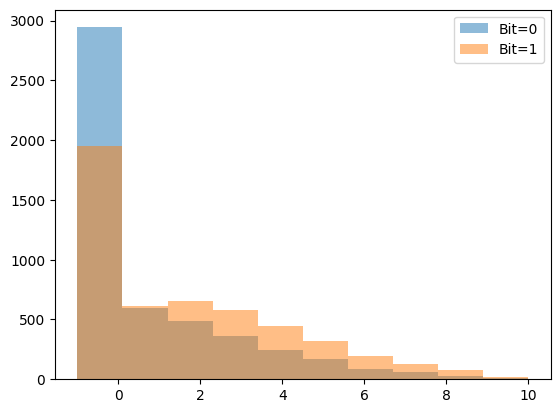

Neuron 0, 0.005465581760982607, 0.5227:    0: 0.6259009838104248, 128: 1.673611044883728


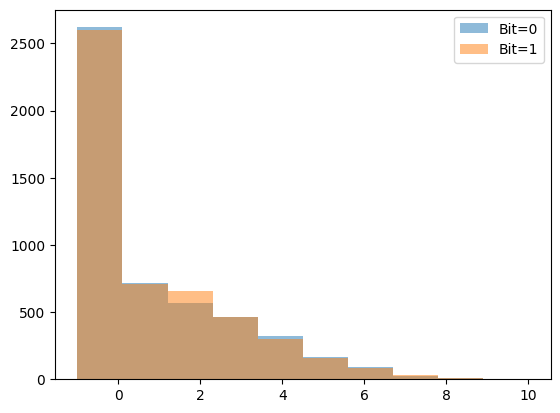

Neuron 1, 0.050741832985120645, 0.4912:    0: 0.7535069584846497, 128: 0.7543352842330933


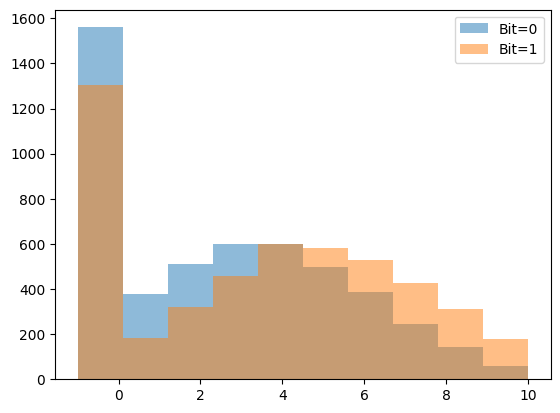

Neuron 2, 4.44667304278551, 0.7175:    0: 2.4848122596740723, 128: 3.593733310699463


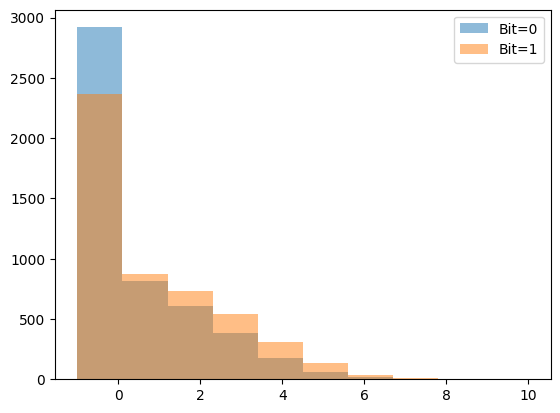

Neuron 3, 0.0339568093951557, 0.4883:    0: 0.33781349658966064, 128: 0.7972466945648193


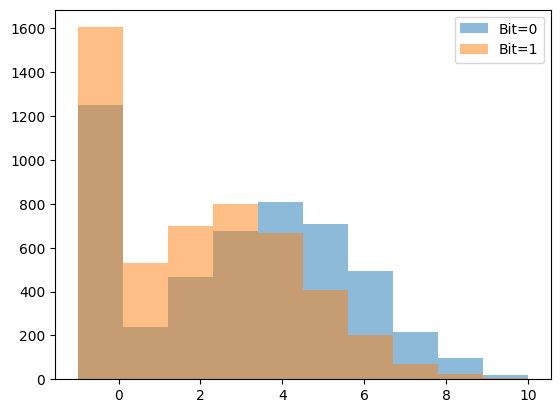

Neuron 4, 0.005472965818488351, 0.7193:    0: 2.8493435382843018, 128: 1.8275783061981201


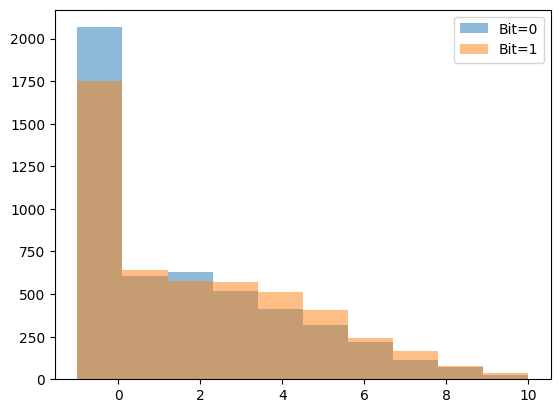

Neuron 5, 0.011369886490497846, 0.6287:    0: 1.5553550720214844, 128: 1.95320725440979


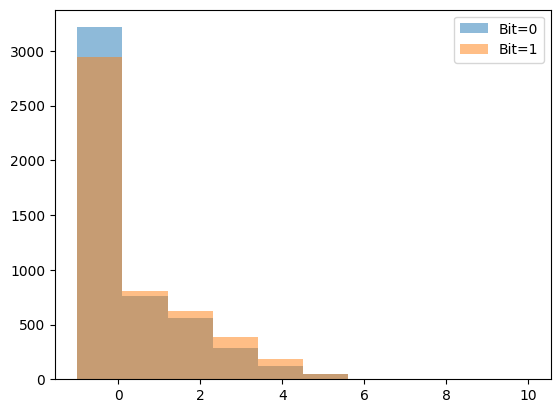

Neuron 6, 0.008326161112369498, 0.3975:    0: 0.11501314491033554, 128: 0.30487340688705444


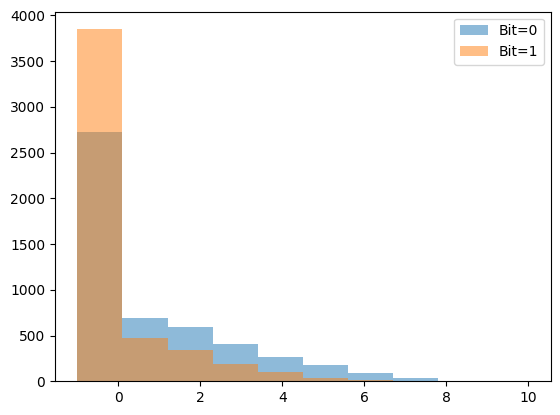

Neuron 7, 0.04316216719931837, 0.3545:    0: 0.6752739548683167, 128: -0.21479444205760956


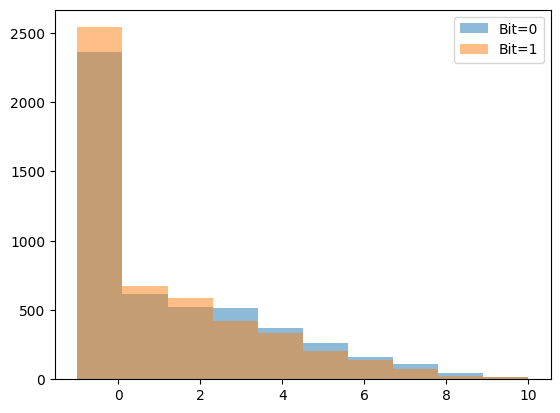

IndexError: index 8 is out of bounds for axis 0 with size 8

In [56]:
bins = np.linspace(-1, 10, 11)
min_indices= tmp_att.shape[0] * 9//256 

for neuron in range(tmp.shape[1]):
    for j in [0, 1]:

        #indices = np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8)) ==j)[0]
        indices = np.where(dataset.share5_attack[target_byte]  % 2 ==j)[0]
        plt.hist(tmp_att[indices, neuron], bins, label=f"Bit={j}", alpha=0.5)
    plt.legend()
    plt.show()

    mean, var = np.average(tmp_att[:, neuron]), np.std(tmp_att[:, neuron])
    avg0 = np.average(tmp_att[np.where(dataset.share5_attack[target_byte]  % 2 ==0)[0], neuron])
    avg128 = np.average(tmp_att[np.where(dataset.share5_attack[target_byte]% 2 ==1)[0], neuron])
    num_activs = len(np.where(tmp_att[:, neuron] > 0)[0])/tmp_att.shape[0]
    #avg255 = np.average(tmp_att[np.where(dataset.share5_attack[target_byte] == 255)[0], neuron])
    print(f"Neuron {neuron}, {snr[neuron]}, {num_activs}:    0: {avg0}, 128: {avg128}")

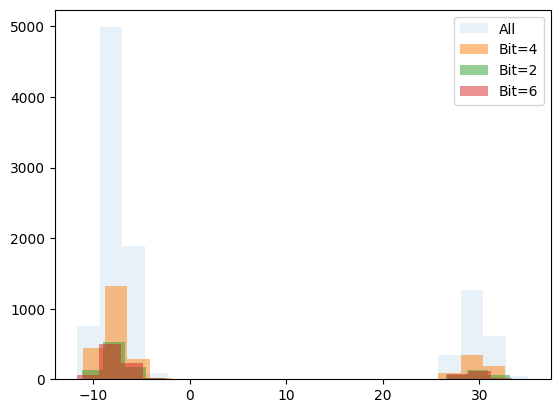

Neuron 0, 0.005465581760982607, 0.228:    0: 0.806193470954895, 128: 0.7497852444648743


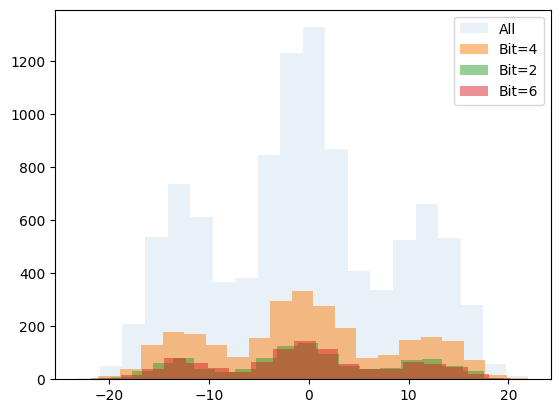

Neuron 1, 0.050741832985120645, 0.4638:    0: -0.6384695172309875, 128: -0.6158254742622375


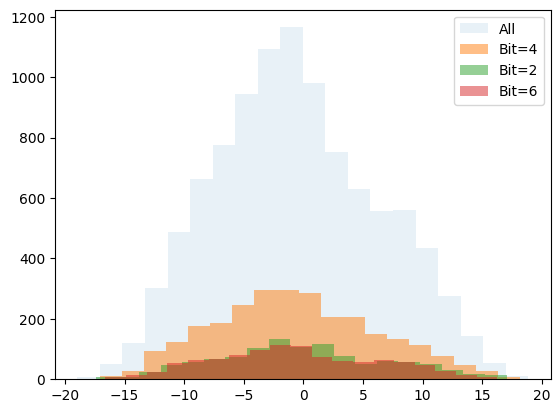

Neuron 2, 4.44667304278551, 0.4371:    0: -0.5812019109725952, 128: -0.5889751315116882


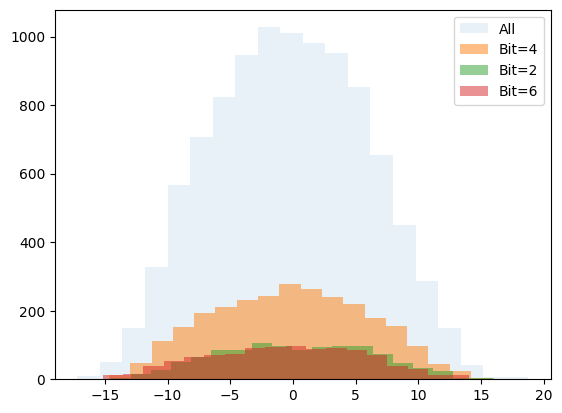

Neuron 3, 0.0339568093951557, 0.4824:    0: -0.4823727309703827, 128: -0.10898622125387192


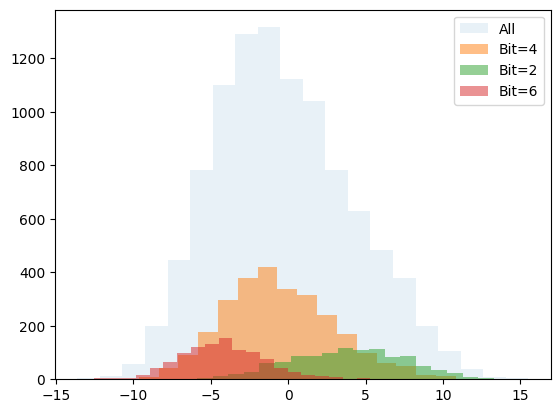

Neuron 4, 0.005472965818488351, 0.4378:    0: 0.3725030720233917, 128: -0.9573614001274109


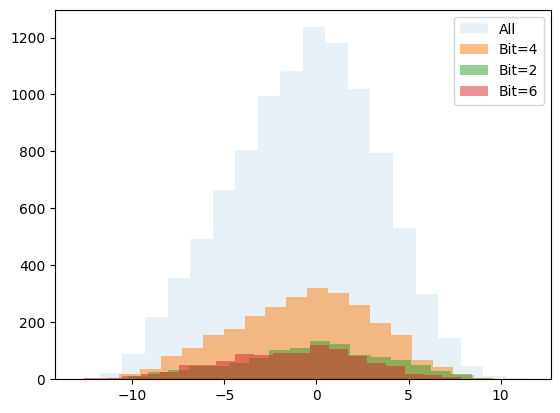

Neuron 5, 0.011369886490497846, 0.4543:    0: -3.1735429763793945, 128: 1.6711536645889282


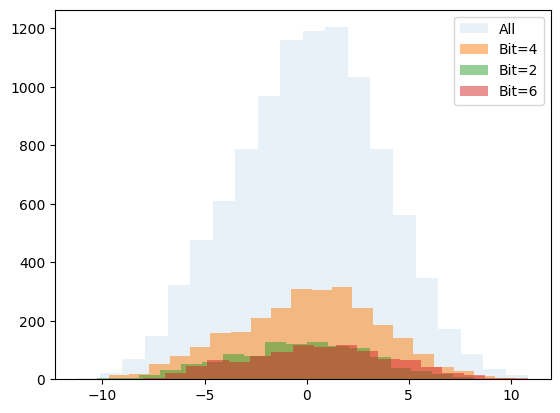

Neuron 6, 0.008326161112369498, 0.5241:    0: 0.43814244866371155, 128: -0.22354429960250854


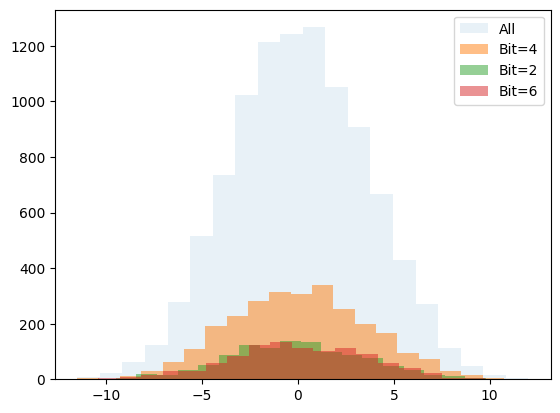

Neuron 7, 0.04316216719931837, 0.5026:    0: 0.2316388636827469, 128: -0.0722464770078659


In [48]:
bins = 20
min_indices= tmp_att.shape[0] * 9//256
N_COMP = 8
pca = PCA(n_components=N_COMP)
pca.fit(tmp)
s1_prof = pca.transform(tmp)
s1_att = pca.transform(tmp_att)

weird_comp_on = np.where(s1_att[:, 0] > 0)[0]
#print(weird_comp_on, dataset.share1_attack[target_byte, weird_comp_on], dataset.share2_attack[target_byte, weird_comp_on]),  min(dataset.share5_attack[target_byte, weird_comp_on]), min(dataset.share6_attack[target_byte, weird_comp_on]))
snr = snr_fast(s1_prof, dataset.share5_profiling[target_byte])
easy_list = np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==0)[0]
easy_list = np.append(easy_list, np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==1)[0])
# easy_list = np.append(easy_list, np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==7)[0])
# easy_list = np.append(easy_list, np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==8)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==1)[0])
# easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==7)[0])
# easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==8)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==0)[0])
# hard_list = easy_list.copy()
easy_list = np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==0)[0]
easy_list = np.append(easy_list, np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==1)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==7)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8))==8)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==1)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==7)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==8)[0])
easy_list = np.append(easy_list, np.where(hw(dataset.share6_attack[target_byte].astype(np.uint8))==0)[0])
hard_list = [item for item in range(s1_att.shape[0]) if item not in easy_list]
for neuron in range(N_COMP):
    plt.hist(s1_att[:, neuron], bins, label=f"All", alpha=0.1)
    for j in [4, 2, 6]:
        hw_list = [5, 1]
        #indices = np.where(hw(dataset.share5_attack[target_byte].astype(np.uint8)) ==j)[0]
        indices = np.where(hw(dataset.share1_attack[target_byte].astype(np.uint8)) ==j)[0] 
        plt.hist(s1_att[indices, neuron], bins, label=f"Bit={j}", alpha=0.5)
        #plt.hist(s1_att[hard_list, neuron], bins, label=f"Bit=asr", alpha=0.5)
        # plt.scatter(s1_att[indices, 0], s1_att[indices, 1], label=f"Bit={j}", alpha=0.5)
        # indices = np.where(dataset.share2_attack[target_byte]  % 2 ==j)[0]
        # plt.hist(s1_att[indices, neuron], bins, label=f"Bit S6={j}", alpha=0.5)
        pass

    indices = np.where(dataset.share2_attack[target_byte, :] + dataset.share6_attack[target_byte, :] == 0)[0] 
    #     #plt.hist(s1_att[indices, neuron], bins, label=f"Bit={j}", alpha=0.5)
    # plt.scatter(s1_att[indices, 0], s1_att[indices, neuron], label=f"High", alpha=0.3)
    # indices = np.where(dataset.share2_attack[target_byte, :] + dataset.share6_attack[target_byte, :] > 0)[0]  
    #     #plt.hist(s1_att[indices, neuron], bins, label=f"Bit={j}", alpha=0.5)
    # plt.scatter(s1_att[indices, 0], s1_att[indices, neuron], label=f"Low", alpha=0.3)
    # # plt.hist(s1_att[easy_list, neuron], bins, label=f"EASY", alpha=0.5)
    # # plt.hist(s1_att[hard_list, neuron], bins, label=f"HARD", alpha=0.5)
    plt.legend()
    plt.show()

    mean, var = np.average(s1_att[:, neuron]), np.std(s1_att[:, neuron])
    avg0 = np.average(s1_att[np.where(dataset.share2_attack[target_byte]  % 2 ==0)[0], neuron])
    avg128 = np.average(s1_att[np.where(dataset.share2_attack[target_byte]% 2 ==1)[0], neuron])
    num_activs = len(np.where(s1_att[:, neuron] > 0)[0])/s1_att.shape[0]
    #avg255 = np.average(tmp_att[np.where(dataset.share5_attack[target_byte] == 255)[0], neuron])
    print(f"Neuron {neuron}, {snr[neuron]}, {num_activs}:    0: {avg0}, 128: {avg128}")

In [53]:
epoch = 15
model.load_weights(f"model_checkpoints/mlp_ascadr_{epoch:02d}.weights.h5")
layer = 1
outputs = [model.layers[layer].output]
new_model = Model(model.inputs, outputs)
tmp =  new_model.predict(dataset.x_profiling)
#print(tmp.shape)
tmp_att = new_model.predict(dataset.x_attack).copy()

pca = PCA(n_components=N_COMP)
pca.fit(tmp)
s1_prof = pca.transform(tmp)
s1_att = pca.transform(tmp_att)
new_model_out= Model(model.layers[layer+1].input, model.layers[-1].output)
COMP =2
weird_comp_off = np.where(s1_att[:, COMP] < 0)[0]
weird_comp_on = np.where(s1_att[:, COMP] > 0)[0]
orig_preds = new_model_out.predict(pca.inverse_transform(s1_att))
orig_preds_restrict = new_model_out.predict(pca.inverse_transform(s1_att[weird_comp_on]))
orig_preds_off = new_model_out.predict(pca.inverse_transform(s1_att[weird_comp_off]))

patched_activs = s1_att.copy()
for comp in range(N_COMP):
    if not comp == COMP:
        continue
    patched_activs[:, comp] *= 0

#patched_activs[:, COMP] *= 0
#patched_activs[weird_comp_off, 1] = 15
#print(patched_activs)
patched_preds_restrict = new_model_out.predict(pca.inverse_transform(patched_activs[weird_comp_on]))
patched_preds_off = new_model_out.predict(pca.inverse_transform(patched_activs[weird_comp_off]))
from profiling_and_attack import information
print(information(orig_preds, dataset.attack_labels, 256))
print(information(orig_preds_off, dataset.attack_labels[weird_comp_off], 256))
print(information(patched_preds_off, dataset.attack_labels[weird_comp_off], 256))

print(information(orig_preds_restrict, dataset.attack_labels[weird_comp_on], 256))
print(information(patched_preds_restrict, dataset.attack_labels[weird_comp_on], 256))


176/176 [==============================] - 0s 879us/step
PI: 0.9817405341398073
0.9817405341398073
PI: 0.925161880852005
0.925161880852005
PI: -1.111949174810491
-1.111949174810491
PI: 1.0187875868565843
1.0187875868565843
PI: -1.1584456402538015
-1.1584456402538015


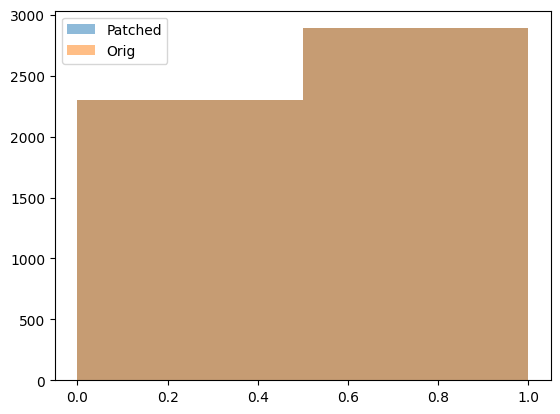

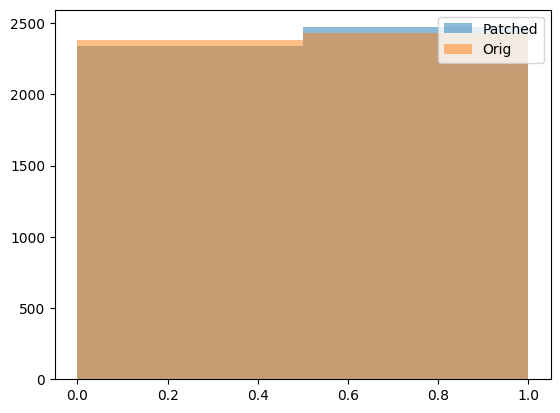

In [28]:
# print(np.max(orig_preds, axis=1))
# for i in range(len(weird_comp_off)):
#     print(np.argmax(patched_preds_off[i]))
#plt.hist(np.argmax(orig_preds, axis=1) %2, 2, label="All", alpha=0.5)
plt.hist(hw(np.argmax(patched_preds_off, axis=1))%2, 2, label="Patched", alpha=0.5)
plt.hist(hw(np.argmax(orig_preds_off, axis=1))%2, 2, label="Orig", alpha=0.5)
plt.legend()
plt.show()
plt.close()
#plt.hist(np.argmax(orig_preds, axis=1) % 2, 2, label="All", alpha=0.5)
plt.hist(hw(np.argmax(patched_preds_restrict, axis=1))%2 , 2, label="Patched", alpha=0.5)
plt.hist(hw(np.argmax(orig_preds_restrict, axis=1))%2, 2, label="Orig", alpha=0.5)
plt.legend()
plt.show()
# print(np.argmax(patched_preds_restrict, axis=1))
# print(np.argmax(orig_preds_restrict - patched_preds_restrict, axis=1))

In [24]:
from profiling_and_attack import information
print(information(orig_preds, dataset.attack_labels, 256))
print(information(orig_preds_off, dataset.attack_labels[weird_comp_off], 256))
print(information(patched_preds_off, dataset.attack_labels[weird_comp_off], 256))

print(information(orig_preds_restrict, dataset.attack_labels[weird_comp_on], 256))
print(information(patched_preds_restrict, dataset.attack_labels[weird_comp_on], 256))

PI: 0.8160489066373656
0.8160489066373656
PI: 0.7133758127592317
0.7133758127592317
PI: 0.6496094523385221
0.6496094523385221
PI: 0.8457539549991759
0.8457539549991759
PI: 0.6953451495168218
0.6953451495168218


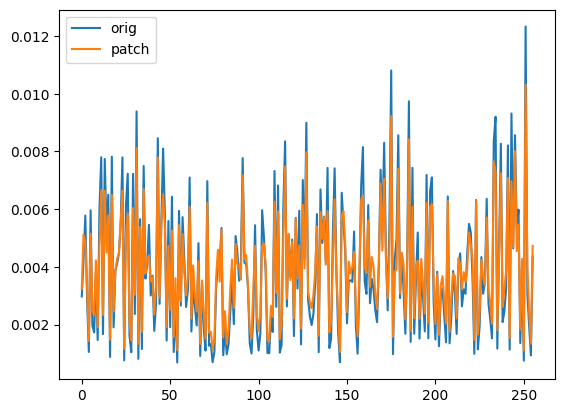

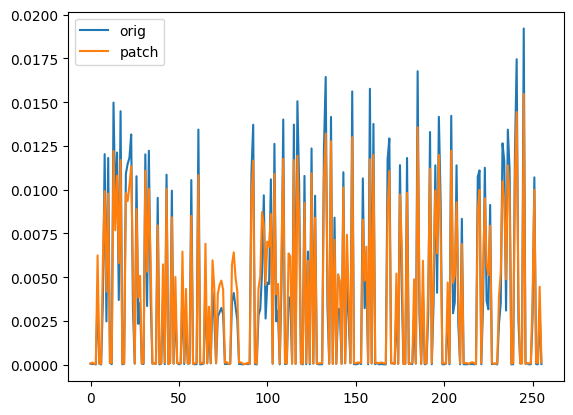

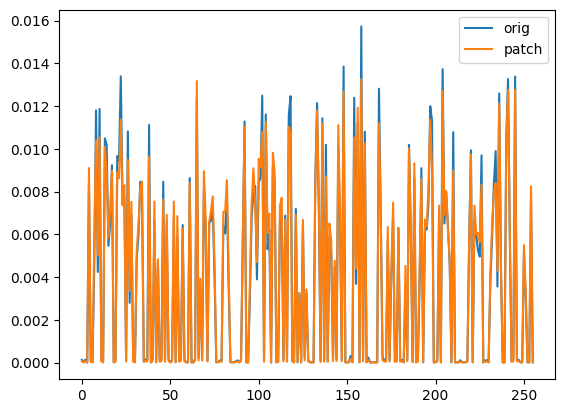

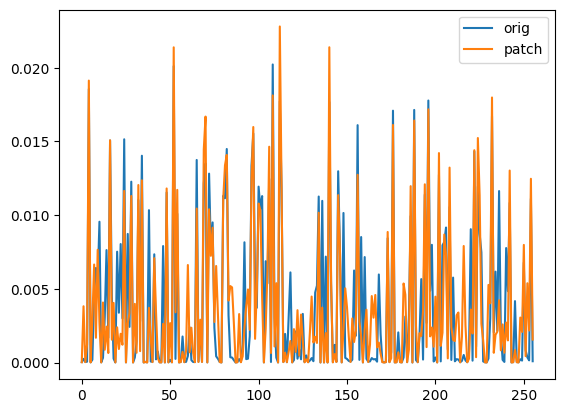

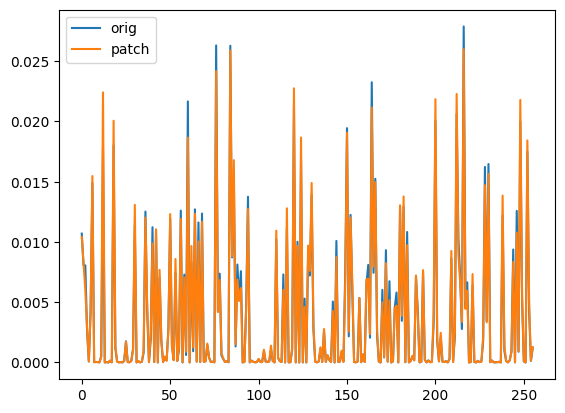

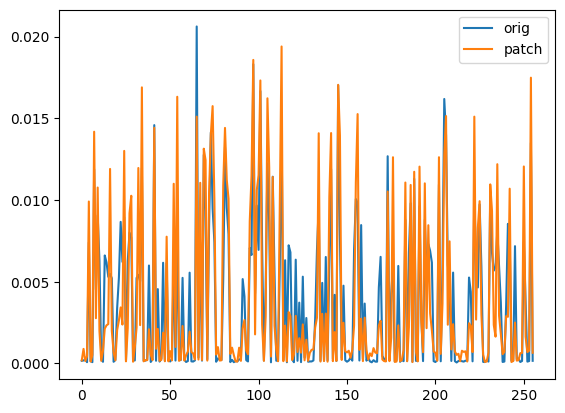

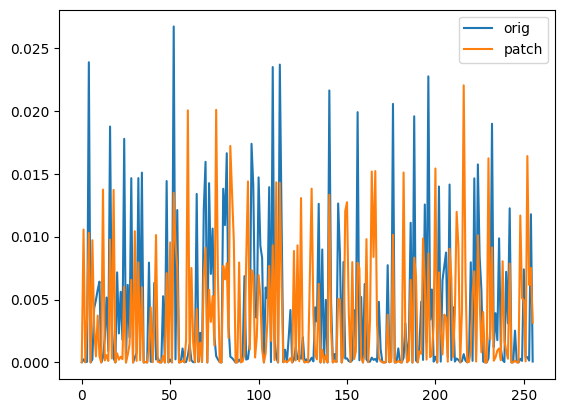

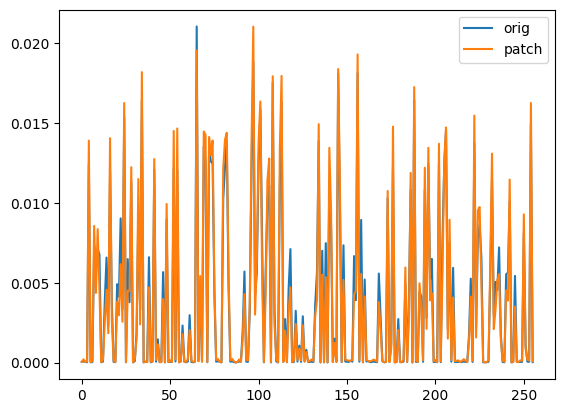

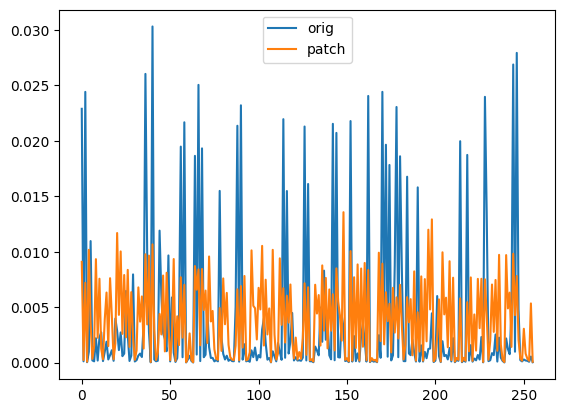

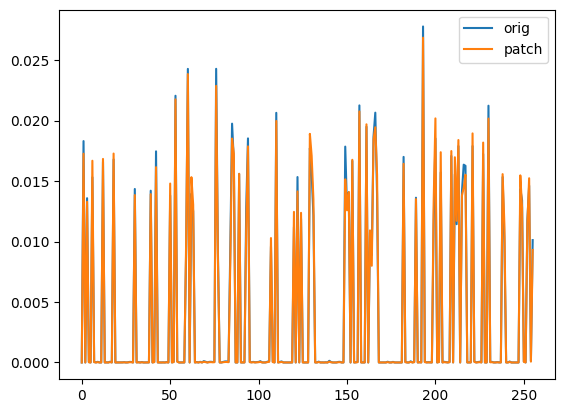

In [13]:
#plt.plot(np.sum(np.log(orig_preds), axis=0), label="All")
for j in range(10):
    plt.plot(orig_preds_restrict[j], label="orig")
    plt.plot(patched_preds_restrict[j], label="patch")
    plt.legend()
    plt.show()